# Matplotlib

In [12]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import pandas as pd
import os
from seaborn import heatmap

AttributeError: module 'matplotlib.cm' has no attribute 'register_cmap'

In [5]:
# Set and print the current working directory
import os
os.chdir("/home/lyonsja/Python/Data")
print(os.getcwd())

/home/lyonsja/Python/Data


In [8]:
t=pd.read_csv('TrolleyGAR.csv')
t.columns=['provider','date','total8am','total8pm','total2pm']
t.date=pd.to_datetime(t.date, format='%d/%m/%Y')
t['year']=t.date.dt.year
t['month']=t.date.dt.month
t['day']=t.date.dt.day
t=t.fillna(0)
t.head()

,provider,date,total8am,total8pm,total2pm,year,month,day
0,101,2013-01-01,1.0,0.0,2,2013,1,1
1,102,2013-01-01,12.0,8.0,11,2013,1,1
2,108,2013-01-01,4.0,10.0,9,2013,1,1
3,201,2013-01-01,3.0,4.0,9,2013,1,1
4,202,2013-01-01,0.0,0.0,5,2013,1,1


#### Grouped Bar Chart

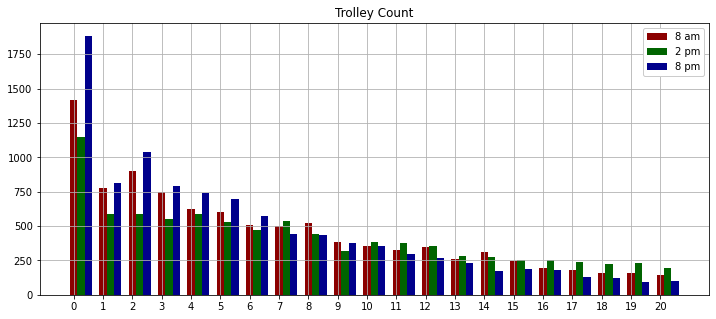

In [9]:
value=list(range(21))
counts8am=[len(t[(t.year==2019) & (t['total8am']==i)]) for i in value]
counts2pm=[len(t[(t.year==2019) & (t['total2pm']==i)]) for i in value]
counts8pm=[len(t[(t.year==2019) & (t['total8pm']==i)]) for i in value]

fig, ax = plt.subplots(figsize=(12,5))
for offset, h, l, col in zip([0,0.25,0.5], 
                          [counts8am,counts2pm,counts8pm],
                          ['8 am','2 pm','8 pm'],
                          ['DarkRed','DarkGreen','DarkBlue']):
    xAxis=[i+offset for i in value]
    ax.bar(x=xAxis, height=h, color=col, label=l, width=.25)
ax.legend(framealpha=1)
ax.grid()
ax.set_title('Trolley Count')
ax.set_xticks(value)
plt.show()

#### Heatmap

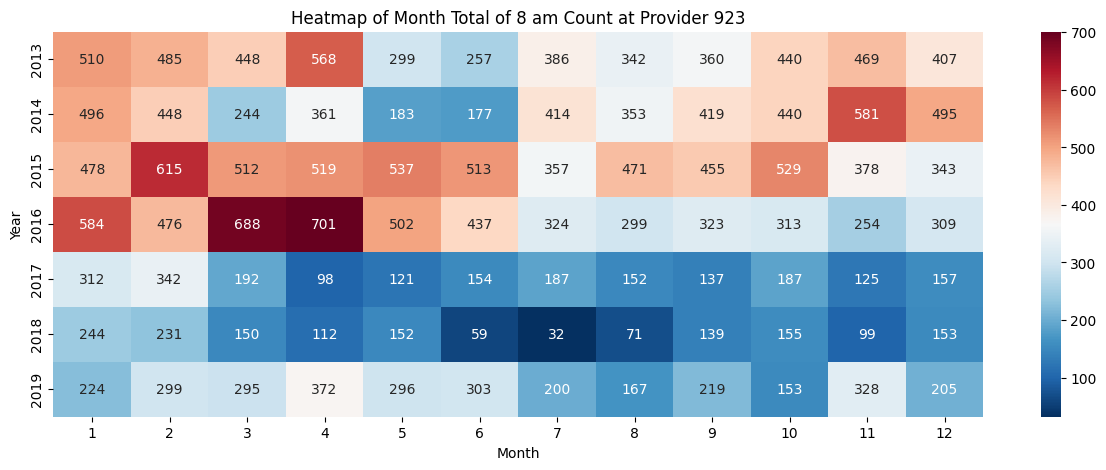

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(15,5))
pivotDF=t[(t.provider==923) & (t.year < 2020)]

pivotDF=pivotDF.groupby(by=['year','month'], as_index=False)
# as_index=False: we don't a new column for index.

pivotDF=pivotDF.aggregate({'total8am':'sum'})
pivotDF['total8am']=pivotDF['total8am'].astype(int)
pivotDF=pivotDF.pivot(index='year', columns='month',values='total8am')

sns.heatmap(pivotDF, annot=True, fmt='.0f', cmap='RdBu_r')
# annot=True: print the values in each tile.
# fmy='.0f': format the values as integers.
# cmap='RdBu_r': the _r reverses the colormap so that blue is low and red is high.

ax.set_title('Heatmap of Month Total of 8 am Count at Provider 923')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.show()

#### Histogram

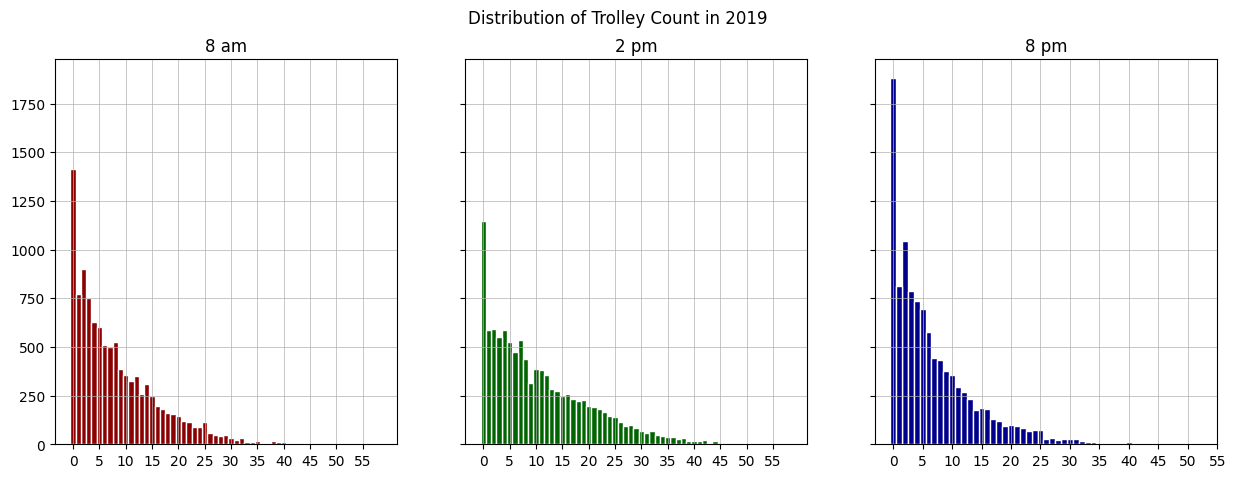

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15,5), sharey=True)
val_list=['total8am','total2pm','total8pm']
title_list=['8 am','2 pm','8 pm']
col_list=['DarkRed','DarkGreen','DarkBlue']
for i in range(3):
    countsDF=pd.DataFrame(t[t.year==2019][val_list[i]].value_counts())
    vals=list(countsDF.index)
    counts=list(countsDF['count'].values)
    ax[i].bar(x=vals, height=counts, width=1, color=col_list[i], align='center', edgecolor='white')
    ax[i].set_title('{}'.format(title_list[i]))
    ax[i].grid(linewidth=.5)
    ax[i].set_xticks(range(0,60,5))
fig.suptitle('Distribution of Trolley Count in 2019')
plt.show()

#### Moving Average

In [6]:
t2=t.query("date < '2021-01-01'")[['date','total8am','provider',
                                   'year','month','day']].reset_index(drop=True)

t2['30DMA']=0
for i in range(len(t2)):
    provider_i = t2.loc[i, 'provider']
    date_i = t2.loc[i, 'date']
    last_30_days = pd.date_range(end=date_i, periods=30)
    moving_average_i = t2[(t2.date.isin(last_30_days)) & (t2.provider==provider_i)].total8am.mean()
    t2.loc[i, '30DMA'] = moving_average_i

t2=t2.sort_values(['provider','date']).reset_index(drop=True)
t2.tail()

,date,total8am,provider,year,month,day,30DMA
84486,2020-12-27,4.0,1049,2020,12,27,5.033333
84487,2020-12-28,4.0,1049,2020,12,28,5.133333
84488,2020-12-29,8.0,1049,2020,12,29,5.300000
84489,2020-12-30,12.0,1049,2020,12,30,5.500000
84490,2020-12-31,6.0,1049,2020,12,31,5.400000


In [34]:
provider_list=list(t2.provider.unique())
for i in [101,305]:
    provider_list.remove(i)

In [53]:
fig_rows=len(provider_list)//2 + 1

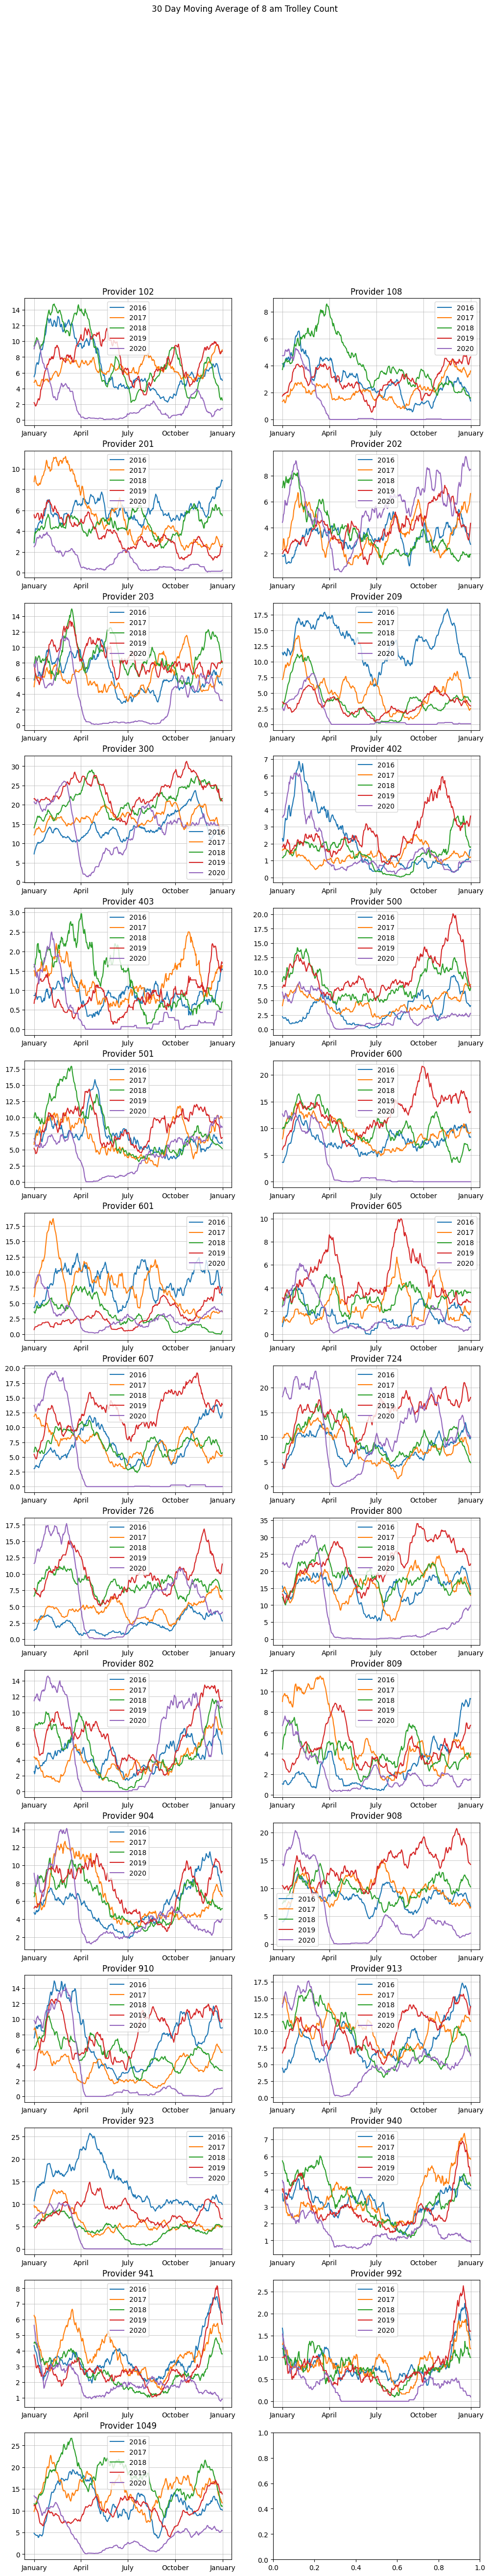

In [56]:
fig, ax = plt.subplots(nrows=fig_rows, ncols=2, figsize=(12, 4*fig_rows))
xticks=pd.to_datetime(['2020-01-01','2020-04-01','2020-07-01','2020-10-01','2021-01-01'])
xlabs=['January','April','July','October','January']
plot_titles = ['Provider '+str(i) for i in provider_list]
fig.suptitle('30 Day Moving Average of 8 am Trolley Count')
ax=ax.ravel()

for i in range(len(provider_list)):
    plot_df=t2[t2.provider==provider_list[i]].dropna()
    plot_df['chart_date']=plot_df.date.dt.strftime(str(2020)+'-%m-%d')
    plot_df.loc[(plot_df.month==2) & (plot_df.day==29),'chart_date'] = pd.NA
    plot_df['chart_date']=pd.to_datetime(plot_df.chart_date)
    plot_df=plot_df.query("year > 2015").pivot(index='chart_date', 
                                               columns='year', 
                                               values='30DMA').dropna()
    ax[i].plot(plot_df)
    ax[i].legend(labels=['2016','2017','2018','2019','2020'])
    ax[i].set_title(plot_titles[i])
    ax[i].set_xticks(ticks=xticks, labels=xlabs)
    ax[i].set_xlabel('')
    ax[i].grid(linewidth=.5)
    
#ax[1].annotate(text='COVID-19\nPandemic', xy=(pd.to_datetime('2020-03-09'),7.8), 
 #           xytext=(pd.to_datetime('2020-07-01'),17.6), 
  #          arrowprops=dict(facecolor='black', shrink=0.01, width=1, headwidth=7))
plt.show()

#### Horizontal Bar Chart

In [65]:
df_list=[]
years=['2016','2017','2018','2019']
for i in years:
    plot_yyyy=t.query('year =='+i+'').groupby(
        by='provider', 
        as_index=False).aggregate({'total8am':'mean'})
    plot_yyyy['year']=int(i)
    plot_yyyy=plot_yyyy.sort_values('total8am', ascending=True).head(10)
    exec("plot_"+i+" = plot_yyyy")
    exec("df_list.append(plot_"+i+")")

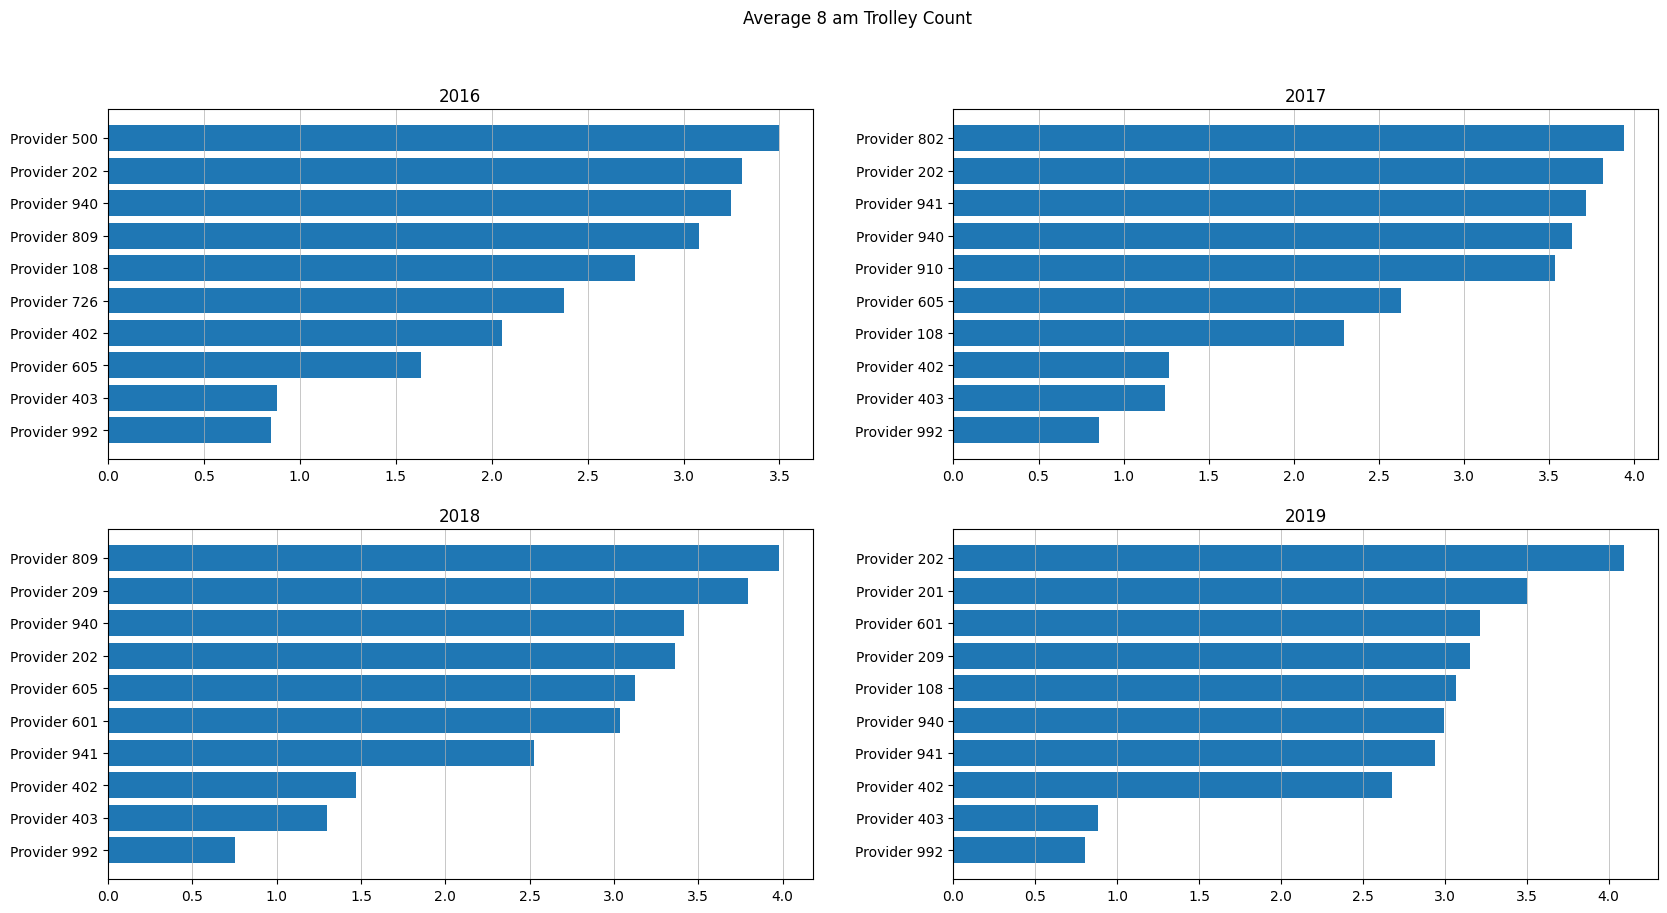

In [73]:
fig, ax = plt.subplots(2,2, figsize=(20,10))
fig.suptitle('Average 8 am Trolley Count')
ax=ax.ravel()
for i in range(len(years)):
    plot_df_i=df_list[i]
    hosps=['Provider '+str(i) for i in plot_df_i.provider]
    plot_df_i.index=hosps
    ax[i].barh(plot_df_i.index, plot_df_i.total8am)
    ax[i].set_title(years[i])
    ax[i].grid(linewidth=.5, axis='x')
plt.show()

#### Scatterplot with Line

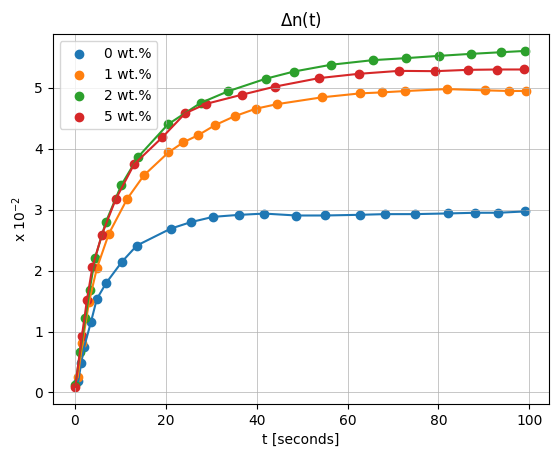

In [6]:
data=pd.read_csv('C:/Users/C10381149/OneDrive - Technological University Dublin/Documents/PhD Documents/Extracted Data/Cody 2014 Effect Fig 7a.csv')

fig, ax = plt.subplots()
for i in data['wt.pc'].unique():
    plot_df=data.loc[data['wt.pc']==i,].sort_values('time')
    ax.scatter(x=plot_df['time'], 
               y=1e3*plot_df['deltan'],
               label=str(int(1e2*i))+' wt.%')
    ax.plot(plot_df['time'], 
               1e3*plot_df['deltan'])

ax.legend()
ax.set_xlabel('t [seconds]')
ax.set_ylabel('x $10^{-2}$')
ax.set_title('$\Delta$n(t)')
ax.grid(linewidth=.5)
plt.show()